<a href="https://colab.research.google.com/github/Valentinekrafft/Machinelearningproject/blob/main/Machine_learning_Project_idea_valentine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Research Objective

The objective of this project is to investigate whether machine learning techniques can identify and classify stellar populations using data from the Gaia DR3 catalog. Gaia provides a large-scale astronomical dataset containing physical and photometric properties of millions of stars, making it particularly suitable for data-driven analysis.

The main research question of this study is:

**How effectively can machine learning classify stellar types using Gaia DR3 features, and what structure emerges from clustering in high-dimensional stellar data?**

To address this question, we use a subset of Gaia DR3 data containing key stellar variables such as effective temperature, surface gravity, metallicity, photometric magnitudes, color index, and distance. These variables describe fundamental physical properties of stars and allow the identification of stellar populations.

In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv("Mahcine learning data.csv")
df.head()

,source_id,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,teff_gspphot,logg_gspphot,mh_gspphot,distance_gspphot,ag_gspphot,azero_gspphot,ebpminrp_gspphot,radial_velocity
0,7116761616256,45.000073,0.214145,5.184997,45.326016,-52.869739,16.743837,18.321789,15.483147,2.838642,3431.9377,4.8043,0.0664,190.3634,0.6715,1.0512,0.4388,NaN
1,15637976759168,45.194622,0.344149,1.324240,1.941703,-0.181805,13.135885,13.505640,12.597779,0.907861,5741.2190,4.1478,-0.0963,726.2313,0.2220,0.2665,0.1191,-34.489674
2,19520627169536,44.801728,0.256419,0.811850,22.906080,-1.067267,15.119571,15.561551,14.410964,1.150587,5377.4014,3.5049,-0.1291,3084.6410,0.4144,0.5119,0.2220,NaN
3,23025320481152,44.762050,0.320027,0.395950,6.355536,-0.369375,16.331987,16.684546,15.790837,0.893708,5414.0490,4.3982,-0.8515,1784.2523,0.0066,0.0080,0.0036,NaN
4,23811298882176,44.769436,0.330694,1.414525,11.240556,-5.891235,16.890995,17.774360,15.975449,1.798912,4256.0770,4.6447,0.0818,640.4408,0.4639,0.6405,0.2499,NaN


In [9]:
df = df.dropna()

df = df[
    (df["teff_gspphot"] > 2500) &
    (df["teff_gspphot"] < 10000)
]

## Exploratory Data Analysis

This project uses stellar data from the Gaia DR3 catalog. Each row of the dataset represents one star observed by the Gaia space telescope. The selected variables describe the physical and observational properties of stars and are used to explore stellar populations and perform machine learning classification.

The following variables were selected for the analysis:

- **phot_g_mean_mag**: apparent magnitude in the Gaia G band, representing overall brightness
- **phot_bp_mean_mag**: blue photometric band magnitude
- **phot_rp_mean_mag**: red photometric band magnitude
- **bp_rp**: color index (BP − RP), used as an indicator of stellar temperature
- **parallax**: parallax measurement used to estimate stellar distance
- **teff_gspphot**: effective temperature of the star (Kelvin)
- **logg_gspphot**: surface gravity, used to distinguish stellar types (giants vs main sequence)
- **mh_gspphot**: metallicity, indicating chemical composition
- **distance_gspphot**: estimated distance from Gaia photometric model

These variables capture fundamental stellar properties such as temperature, luminosity, size, and composition. They allow us to explore the structure of stellar populations and evaluate whether machine learning can automatically classify stars into meaningful groups.

In [10]:
df.describe()

,source_id,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,teff_gspphot,logg_gspphot,mh_gspphot,distance_gspphot,ag_gspphot,azero_gspphot,ebpminrp_gspphot,radial_velocity
count,1.570200e+04,15702.000000,15702.000000,15702.000000,15702.000000,15702.000000,15702.000000,15702.000000,15702.000000,15702.000000,15702.000000,15702.000000,15702.000000,15702.000000,15702.000000,15702.000000,15702.000000,15702.000000
mean,7.498426e+15,47.535983,6.304388,2.345690,8.542977,-9.857597,13.556320,14.076105,12.888854,1.187251,5393.759353,4.155936,-0.367994,712.213034,0.447630,0.562871,0.241997,6.984279
std,4.309597e+15,3.809228,2.566085,2.425416,29.056543,20.556849,1.281143,1.364887,1.230455,0.346411,672.036166,0.499286,0.373713,699.504387,0.319352,0.409128,0.173276,37.082172
min,3.865554e+10,39.428974,0.019880,-3.463069,-232.457233,-515.645438,5.860868,6.090557,5.258683,0.014815,2962.751200,0.276100,-4.072400,8.613100,0.000000,0.000000,0.000000,-545.814760
25%,3.767790e+15,44.558270,4.358466,1.151356,-0.975685,-14.303116,12.972697,13.428312,12.342584,0.956850,4989.168925,4.060150,-0.583600,354.267075,0.199325,0.244325,0.106900,-14.070856
50%,7.537294e+15,47.193054,6.379281,1.730258,4.824125,-6.610664,13.887571,14.372650,13.226475,1.119515,5474.704200,4.279350,-0.337700,552.767200,0.397250,0.496800,0.214000,7.665888
75%,1.123121e+16,50.445477,8.405696,2.757532,13.282939,-1.102826,14.484423,14.998289,13.796998,1.334810,5814.269350,4.469000,-0.121800,819.397025,0.631875,0.798975,0.342500,28.614660
max,1.552095e+16,56.177064,11.950964,116.267814,1741.874611,137.491712,15.741006,17.654345,14.531093,3.763448,9989.355000,5.111900,0.788300,15285.828000,2.808400,3.631300,1.537300,291.462250


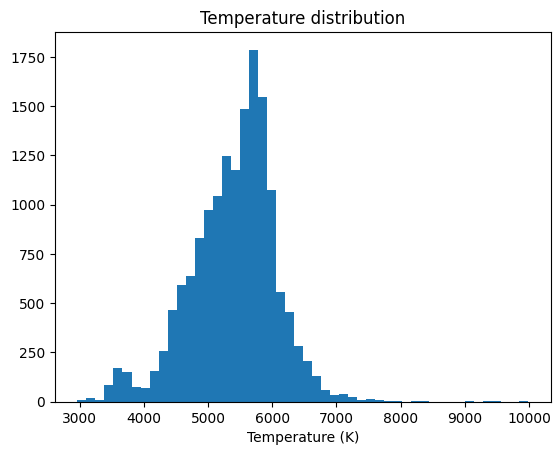

In [11]:
import matplotlib.pyplot as plt

plt.hist(df["teff_gspphot"], bins=50)
plt.title("Temperature distribution")
plt.xlabel("Temperature (K)")
plt.show()

### Temperature Distribution

The histogram of stellar temperature shows how stars are distributed across different temperature ranges. Most stars are concentrated in the lower temperature range, corresponding to cooler stars such as red dwarfs. Fewer stars appear at higher temperatures, which correspond to massive and hotter stars.

This distribution reflects the natural stellar population in the Milky Way, where cooler stars are more common. Understanding this distribution helps identify whether the dataset is balanced and suitable for machine learning classification.

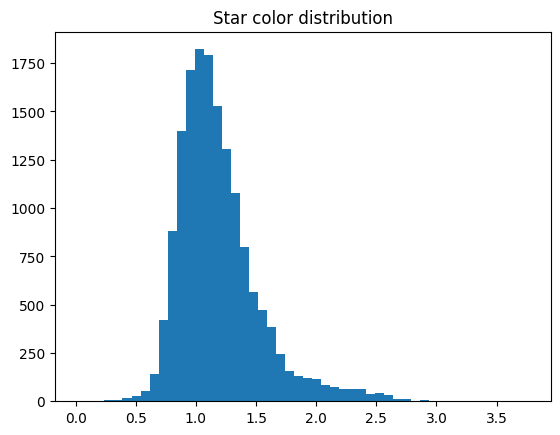

In [12]:
plt.hist(df["bp_rp"], bins=50)
plt.title("Star color distribution")
plt.show()

### Color Index Distribution (BP − RP)

The BP−RP color index measures the difference between blue and red magnitudes and is strongly correlated with stellar temperature. Lower values correspond to blue, hotter stars, while higher values correspond to red, cooler stars.

The distribution of BP−RP values helps identify different stellar populations and provides an initial view of how stars are grouped based on their temperature and spectral characteristics.

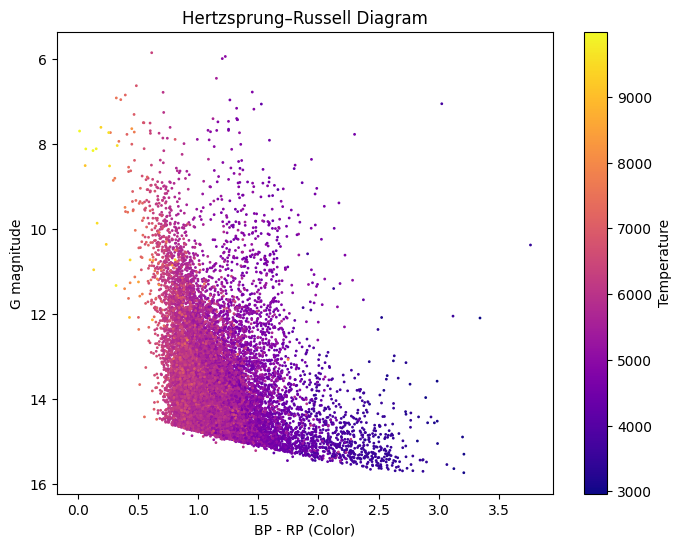

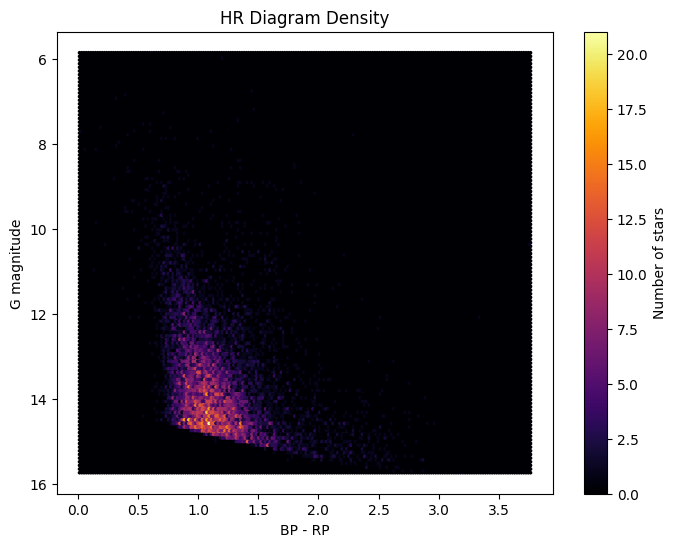

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df["bp_rp"],
    df["phot_g_mean_mag"],
    c=df["teff_gspphot"],
    s=1,
    cmap="plasma"
)

plt.gca().invert_yaxis()

plt.xlabel("BP - RP (Color)")
plt.ylabel("G magnitude")
plt.title("Hertzsprung–Russell Diagram")

cbar = plt.colorbar()
cbar.set_label("Temperature")

plt.show()
plt.figure(figsize=(8,6))

plt.hexbin(
    df["bp_rp"],
    df["phot_g_mean_mag"],
    gridsize=200,
    cmap="inferno"
)

plt.gca().invert_yaxis()

plt.xlabel("BP - RP")
plt.ylabel("G magnitude")
plt.title("HR Diagram Density")

plt.colorbar(label="Number of stars")

plt.show()

### Hertzsprung–Russell Diagram

The Hertzsprung–Russell (HR) diagram plots stellar color (BP−RP) against magnitude. This diagram is one of the most important tools in astrophysics because it reveals the structure of stellar populations.

Distinct regions can be observed:

- Main sequence stars form a diagonal band
- Giant stars appear above the main sequence
- Cooler stars appear toward the right side
- Hotter stars appear toward the left side

The presence of these structures confirms that the Gaia dataset contains meaningful astrophysical information and that machine learning methods should be able to identify these populations automatically.

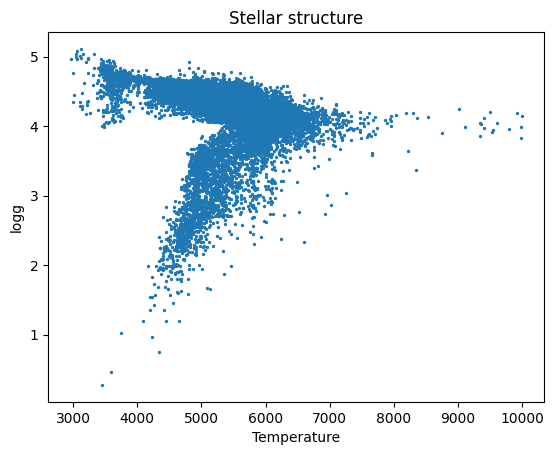

In [14]:
plt.scatter(
df["teff_gspphot"],
df["logg_gspphot"],
s=2
)

plt.xlabel("Temperature")
plt.ylabel("logg")
plt.title("Stellar structure")
plt.show()

### Temperature vs Surface Gravity

This plot shows the relationship between stellar temperature and surface gravity. Surface gravity is a key indicator of stellar type:

- High surface gravity corresponds to main sequence stars
- Low surface gravity corresponds to giant stars
- Intermediate values correspond to subgiants

This visualization allows us to observe how different stellar populations separate in parameter space. These separations provide a strong foundation for supervised machine learning classification.


<Axes: >

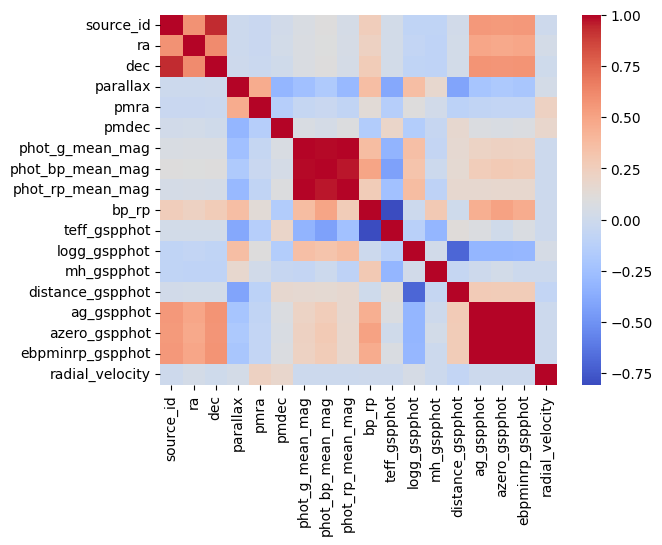

In [15]:
import seaborn as sns

sns.heatmap(df.corr(), cmap="coolwarm")

### Correlation Matrix Analysis

The correlation matrix shows the relationships between the main stellar variables extracted from the Gaia dataset. Strong correlations appear between the photometric magnitudes (phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag), which is expected since they measure brightness in different wavelength bands.

The BP−RP color index is strongly correlated with effective temperature (teff_gspphot), confirming that color is a good proxy for stellar temperature. This is consistent with astrophysical theory, where redder stars are cooler and bluer stars are hotter.

Surface gravity (logg_gspphot) shows moderate correlations with magnitude and temperature, reflecting the structural differences between main sequence stars and giant stars. Giants typically have lower surface gravity and higher luminosity.

Distance-related variables show correlations with extinction parameters (ag_gspphot, azero_gspphot, ebpminrp_gspphot), which is expected since more distant stars are more affected by interstellar dust.

Overall, the correlation matrix confirms that the selected Gaia variables capture meaningful physical relationships between stellar properties. These correlations indicate that machine learning models should be able to learn the structure of stellar populations and classify stars based on their physical characteristics.

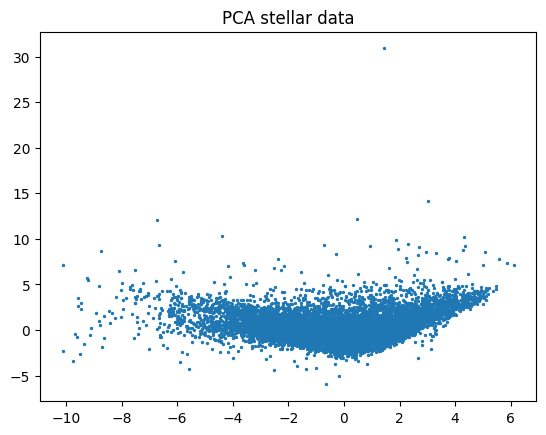

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features = [
"phot_g_mean_mag",
"phot_bp_mean_mag",
"phot_rp_mean_mag",
"bp_rp",
"parallax",
"teff_gspphot",
"logg_gspphot",
"mh_gspphot"
]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], s=2)
plt.title("PCA stellar data")
plt.show()

### Principal Component Analysis (PCA)

Principal Component Analysis is used to reduce the dimensionality of the dataset while preserving the main structure of the data. By projecting stars into two principal components, we can visualize whether natural clusters appear.

If distinct clusters emerge in the PCA plot, this suggests that stars naturally group based on their physical properties. This supports the use of unsupervised learning methods such as clustering and validates the potential for machine learning classification.

The PCA projection provides insight into the structure of high-dimensional stellar data and helps identify patterns that may not be visible in individual variables.

### PCA Analysis

The PCA projection reveals the structure of the stellar dataset in reduced dimensional space. Most stars form a dense continuous distribution, indicating that stellar populations are not completely separated but rather form a gradual sequence.

The curved shape observed in the PCA plot reflects transitions between different stellar populations, such as main sequence stars and giant stars. This suggests that stellar properties vary smoothly rather than forming completely distinct clusters.

A few isolated points appear far from the main distribution. These likely correspond to rare stellar types, extreme physical properties, or potential outliers in the dataset.

The absence of clearly separated clusters indicates that linear dimensionality reduction alone is not sufficient to fully distinguish stellar populations. This motivates the use of non-linear methods such as UMAP or t-SNE, as well as supervised machine learning models for classification.

Overall, the PCA confirms that the Gaia dataset contains structured but overlapping stellar populations, making it suitable for machine learning analysis.

The exploratory data analysis reveals that stellar populations form structured but overlapping distributions in parameter space. The Hertzsprung–Russell diagram highlights distinct stellar regions such as the main sequence and giant branch. The correlation matrix confirms meaningful relationships between physical variables such as temperature, color, and gravity.

The PCA projection shows that stellar populations follow a continuous curved structure rather than forming clearly separated clusters. This indicates that linear separation is not sufficient to distinguish stellar types.

These observations motivate the use of machine learning techniques. First, clustering methods will be applied to identify natural groupings of stars. Then, supervised learning models will be trained to classify stellar types based on their physical properties. This approach allows us to evaluate how effectively machine learning can identify stellar populations in Gaia data.